# Эксперименты с нейросетями: анализ тональности текста

Вы работаете в команде картографического сервиса YouMap, который собирает отзывы о компаниях, организациях, квартирах и других заведениях из разных источников. Команде качества нужно научиться автоматически находить негативные сообщения и передавать их на приоритетную обработку. Ваша задача - подготовить данные, обучить модель и объяснить, какой подход лучше помогает находить негативные отзывы.

Вам предстоит использовать датасет `ds_s26_geo_reviews.csv`.

|Признак|Описание|Комментарий|
|:---|:---|:---|
|text|Текст отзыва|Отзывы для обучения нейросети|
|address|Адрес организации|Только для EDA|
|federal_district|Федеральный округ|Категориальный признак|
|name_ru|Название организации|Только для EDA. <br> Не используйте его для обучения|
|rubrics|Категории, к которым относится организация|Только для EDA|
|rubrics_count|Количество категорий, к которым относится организация|Числовой признак|
|review_len_chars|Длина отзыва в символах|Числовой признак|
|review_len_words|Длина отзыва в словах|Числовой признак|
|emoji_count|Количество эмодзи в отзыве|Числовой признак|
|target|1 - негативный отзыв, оценка 1–2. <br> 0 - остальные отзывы, оценка 3–5.|Целевая переменная|

В проекте вы сравните два способа представить один и тот же текст для нейросети:

*   Числовые признаки текста + MLP.
*   Индексы токенов + эмбеддинги + mean pool +  MLP.

Основная метрика - PR-AUC, вспомогательные - ROC-AUC, precision, recall, F1-мера.

В ячейках с пропусками (`...`) допишите недостающий код. Не меняйте названия ключевых переменных: они используются в следующих блоках.

## Шаг 1. Импорт библиотек, настройка констант, обеспечение воспроизводимости

In [3]:
%pip install -qU scikit-learn numpy pandas matplotlib torch

In [1]:
import random
import re
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset


In [7]:
RANDOM_STATE = 42
DATA_PATH_1 = Path('/content/drive/MyDrive/datasets/ds_s26_geo_reviews.csv')
DATA_PATH_2 = Path("/datasets/ds_s26_geo_reviews.csv")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)


def set_seed(seed: int = RANDOM_STATE) -> None:
    # Зафиксируйте random seed для random, numpy и torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_STATE)

# Определите устройство: cuda по доступности, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive монтирован


## Шаг 2. Загрузка данных и исследовательский анализ

EDA в этом проекте - короткий блок для знакомства с данными, в котором весь код уже написан. Он поможет понять размер датасета, проанализировать целевую переменную, проверить дисбаланс классов и пропуски.

Запустите ячейки, посмотрите на результаты и переходите к оформлению выводов.

In [9]:
# Код для EDA готов: запустите ячейки и изучите выводы
if DATA_PATH_1.exists():
    df = pd.read_csv(DATA_PATH_1, sep=',', decimal='.')
elif DATA_PATH_2.exists():
    df = pd.read_csv(DATA_PATH_2, sep=',', decimal='.')
else:
    raise FileNotFoundError("Путь до датасета неверный")

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head())

Размер датасета: 11796 строк, 10 столбцов


,text,address,federal_district,name_ru,rubrics,rubrics_count,review_len_chars,review_len_words,emoji_count,target
0,Бронировала квартиру в Тюмени. Бронирование пр...,"Челябинск, проспект Ленина, 21В",Уральский ФО,Квартирка,Информационный интернет-сайт;Агентство недвижи...,2,121,14,0,0
1,Праздновали Новый год в этом отеле.\nСамое пот...,"Иркутский район, Листвянское муниципальное обр...",Сибирский ФО,Байкал Хан,Гостиница,1,577,89,0,0
2,"Очень нравится грумер Анна, всегда приветливая...","Московская область, Королёв, Подмосковная улиц...",Центральный ФО,Счастливые хвостатые,"Зоосалон, зоопарикмахерская;Зоомагазин",3,434,67,0,0
3,В городе Салават директора на месте невозможно...,"Республика Башкортостан, Салават, улица Ленина...",Приволжский ФО,Спортмастер,Спортивный магазин;Спортивная одежда и обувь;Т...,3,201,32,0,1
4,Огромное спасибо за заказ.\nЗаказ очень хорошо...,"Москва, Троицкая улица, 7/1с1",Центральный ФО,Дом Чая,Магазин чая;Магазин посуды,2,183,27,0,0


In [10]:
# Типы данных, пропуски и количество уникальных значений
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
}))

,dtype,missing,unique
text,str,0,11796
address,str,0,10614
federal_district,str,0,8
name_ru,str,25,9012
rubrics,str,0,3287
rubrics_count,int64,0,9
review_len_chars,int64,0,1193
review_len_words,int64,0,302
emoji_count,int64,0,22
target,int64,0,2


,target,count,share
0,0,10723,0.909037
1,1,1073,0.090963


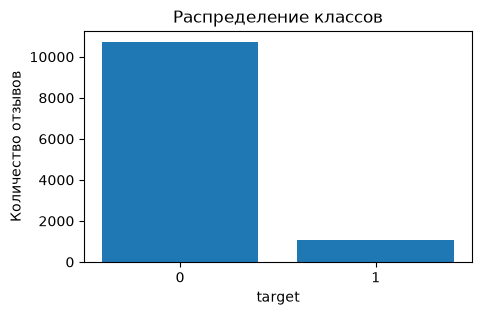

In [11]:
# Распределение классов: количество объектов каждого класса и их доля
target_distribution = (
    df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)
target_distribution["share"] = target_distribution["count"] / len(df)

display(target_distribution)

plt.figure(figsize=(5, 3))
plt.bar(target_distribution["target"].astype(str), target_distribution["count"])
plt.title("Распределение классов")
plt.xlabel("target")
plt.ylabel("Количество отзывов")
plt.show()

In [12]:
pd.set_option("display.max_colwidth", 220)

# Примеры объектов каждого класса: посмотрите, как выглядит текстовая разметка
for class_value, title in [(0, "ненегативные отзывы"), (1, "негативные отзывы")]:
    print(f"Примеры: {title}")
    examples = (
        df[df["target"] == class_value]
        [["text", "federal_district", "rubrics_count", "review_len_words", "emoji_count", "target"]]
        .sample(3, random_state=RANDOM_STATE)
    )
    display(examples)

Примеры: ненегативные отзывы


,text,federal_district,rubrics_count,review_len_words,emoji_count,target
1809,"Спасибо, Дмитрию за грамотный подбор экипировки для детей",Центральный ФО,3,8,0,0
3561,"Мне очень понравилось! Зашла туда случайно, хотелось выпить кофе с чем-нибудь вкусненьким.. Официантка очень приветливая и обходительная, предложила выбрать место, в зале очень уютно. Попробовала тосты с авокадо и Бо...",Центральный ФО,1,43,0,0
10301,"Всё просто супер! В номере есть всё необходимое, для автономного проживания. Особенно радует небольшая кухня с посудой, столовыми приборами, микроволновкой, электрочайником и плитой. А прямо под окнами есть супермарк...",Сибирский ФО,1,116,0,0


Примеры: негативные отзывы


,text,federal_district,rubrics_count,review_len_words,emoji_count,target
10728,"Совершенно отвратительное поведение дирекции: нужно было проехать по дороге (городская территория, как и весь МУП Рынок) - разгрузиться у соседнего здания. Как оказалось, въезд/проезд/пролёт на ранок стоит 800 рублей...",Центральный ФО,1,52,0,1
8118,"Купил велик ребёнку, он сломался через 3 недели эксплуатации, приехали в сервис, но тут его не приняли, записать могут через неделю не раньше, на просьбу уделить 2 минуты и оценить масштаб ремонта тоже отказали, хо...",Центральный ФО,2,88,0,1
11716,Ни в коем случае не посещайте данную мойку!\nПродолжают списывать деньги с карты после единоразового посещения!!!\nСписывают без моего ведома!,Центральный ФО,2,20,0,1


Сформулируйте выводы, кратко ответив на вопросы:

* Насколько классы сбалансированы?

* Почему accuracy здесь может вводить в заблуждение?

* Какие пропуски обнаружились и как с ними нужно поступить?

* Почему важно помнить, что `target` получен из пользовательских оценок, а не ручной разметкой текста?

1. В классах явно просматривается дисбаланс в сторону ненегативных отзывов соотношение почти доходит до 1 к 10. 
2. Accuracy как метрика качества будет не самым удачным решением, так как дисбаланс сделать результат модели завышенным. Даже, если модель будет всегда отвечать, что отзыв ненегативный, то точность модели будет порядка 91% (исходя из данных), что довольно сильно, но на деле от такой модели не будет толка.
3. Пропуск есть только в name_ru - всего 25 пропусков (0,21% от всех данных), так как поле не будет участвовать в обучении, то его можно закрыть обычной заглушкой
4. Target определяется не по содержанию самого текста, а по оценке пользователя: target = 1 соответствует оценке 1-2, а target = 0 оценке 3-5. Поэтому целевая переменная может не всегда точно отражать реальную тональность отзыва. Например, пользователь может поставить низкую оценку, хотя текст отзыва выглядит нейтральным или даже положительным, и наоборот.

## Шаг 3. Подготовка числовых признаков

Для первого эксперимента используйте готовые числовые признаки, закодированный признак `federal_district` и самостоятельно извлечённые из текста числовые показатели:

- `punct_count` - количество знаков препинания.
- `question_count` - количество вопросительных знаков.
- `exclamation_count` - количество восклицательных знаков.
- `newline_count` - количество переносов строк.
- `digit_count` - количество цифр.
- `uppercase_share` - доля заглавных букв среди всех букв.
- `avg_word_len` - средняя длина слова.

Выделив все признаки, разделите данные на обучающую, валидационную и тестовую выборки, а затем подготовьте данные для нейросети, создав объекты классов `Dataset` и `DataLoader`. Это же разделение нужно будет использовать и в эксперименте с текстовой моделью, чтобы сравнение было честным.

Не используйте признаки `name_ru`, `address` и `rubrics` в модели: они нужны для знакомства с данными, но могут привести к запоминанию конкретных организаций или слишком детальных категорий.

In [13]:
df_features = df.copy()
text = df_features["text"].astype(str)
punctuation = string.punctuation + "«»—–…“”„"

# 1. Количество знаков препинания
df_features["punct_count"] = text.apply(
    lambda x: sum(char in punctuation for char in x)
)

# 2. Количество вопросительных знаков
df_features["question_count"] = text.apply(
    lambda x: x.count("?")
)

# 3. Количество восклицательных знаков
df_features["exclamation_count"] = text.apply(
    lambda x: x.count("!")
)

# 4. Количество переносов строк
df_features["newline_count"] = (
    text.str.count("\n") + text.str.count(r"\\n")
)

# 5. Количество цифр
df_features["digit_count"] = text.apply(
    lambda x: sum(char.isdigit() for char in x)
)

# 6. Доля заглавных букв среди всех букв
# Сначала посчитайте общее число букв и число заглавных букв
letters_count = text.apply(
    lambda x: sum(char.isalpha() for char in x)
)
upper_count = text.apply(
    lambda x: sum(char.isupper() for char in x)
)
df_features["uppercase_share"] = upper_count / letters_count
df_features["uppercase_share"] = df_features["uppercase_share"].fillna(0)

# 7. Средняя длина слова
df_features["avg_word_len"] = text.apply(
    lambda x: sum(char.isalpha() for char in x) / len(x.split())
)
df_features["avg_word_len"] = df_features["avg_word_len"].fillna(0)

numeric_features = [
    "rubrics_count",
    "emoji_count",
    "punct_count",
    "question_count",
    "exclamation_count",
    "newline_count",
    "digit_count",
    "uppercase_share",
    "avg_word_len",
]

categorical_features = ["federal_district"]

display(df_features[numeric_features + ["target"]].describe().T)

district_distribution = (
    df_features["federal_district"]
    .value_counts()
    .rename_axis("federal_district")
    .reset_index(name="count")
)
district_distribution["share"] = district_distribution["count"] / len(df_features)
display(district_distribution)

,count,mean,std,min,25%,50%,75%,max
rubrics_count,11796.0,1.982791,1.095271,1.000000,1.0,2.000000,3.00000,10.000000
emoji_count,11796.0,0.320787,2.009054,0.000000,0.0,0.000000,0.00000,173.000000
punct_count,11796.0,12.085792,12.656860,0.000000,5.0,8.000000,14.00000,186.000000
question_count,11796.0,0.054256,0.393383,0.000000,0.0,0.000000,0.00000,10.000000
exclamation_count,11796.0,1.123093,2.346631,0.000000,0.0,0.000000,1.00000,35.000000
newline_count,11796.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000
digit_count,11796.0,1.141997,3.272105,0.000000,0.0,0.000000,1.00000,92.000000
uppercase_share,11796.0,0.993303,0.081565,0.000000,1.0,1.000000,1.00000,1.000000
avg_word_len,11796.0,5.914347,0.940139,2.818182,5.3,5.785714,6.37037,14.666667
target,11796.0,0.090963,0.287569,0.000000,0.0,0.000000,0.00000,1.000000


,federal_district,count,share
0,Центральный ФО,4922,0.417260
1,Северо-Западный ФО,1922,0.162937
2,Южный ФО,1766,0.149712
3,Приволжский ФО,1547,0.131146
4,Сибирский ФО,589,0.049932
5,Уральский ФО,519,0.043998
6,Северо-Кавказский ФО,364,0.030858
7,Дальневосточный ФО,167,0.014157


In [15]:
# Разделите данные на обучающую, валидационную и тестовую выборки в пропорции 70:15:15
# Не забудьте про стратификацию, чтобы сохранить долю негативных отзывов
train_df, temp_df = train_test_split(
    df_features,
    test_size=.3,
    stratify=df_features["target"],
    random_state=RANDOM_STATE,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=.5,
    stratify=temp_df["target"],
    random_state=RANDOM_STATE,
)

split_stats = pd.DataFrame(
    {
        "rows": [len(train_df), len(val_df), len(test_df)],
        "target_share": [
            train_df["target"].mean(),
            val_df["target"].mean(),
            test_df["target"].mean(),
        ],
    },
    index=["обучающая", "валидационная", "тестовая"],
)

display(split_stats)

,rows,target_share
обучающая,8257,0.090953
валидационная,1769,0.091012
тестовая,1770,0.090960


In [17]:
# Создайте scaler для числовых признаков и encoder для federal_district
scaler = StandardScaler()
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Важно: fit только на обучающей выборке, для валидационной и тестовой используйте transform
X_train_num = scaler.fit_transform(train_df[numeric_features])
X_val_num = scaler.transform(val_df[numeric_features])
X_test_num = scaler.transform(test_df[numeric_features])

X_train_cat = one_hot_encoder.fit_transform(train_df[categorical_features])
X_val_cat = one_hot_encoder.transform(val_df[categorical_features])
X_test_cat = one_hot_encoder.transform(test_df[categorical_features])

X_train = np.hstack([X_train_num, X_train_cat]).astype("float32")
X_val = np.hstack([X_val_num, X_val_cat]).astype("float32")
X_test = np.hstack([X_test_num, X_test_cat]).astype("float32")

y_train = train_df["target"].values.astype("float32")
y_val = val_df["target"].values.astype("float32")
y_test = test_df["target"].values.astype("float32")

feature_names = numeric_features + list(
    one_hot_encoder.get_feature_names_out(categorical_features)
)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Количество признаков после кодирования:", len(feature_names))
display(pd.DataFrame({"feature": feature_names}))

X_train: (8257, 17) X_val: (1769, 17) X_test: (1770, 17)
Количество признаков после кодирования: 17


,feature
0,rubrics_count
1,emoji_count
2,punct_count
3,question_count
4,exclamation_count
5,newline_count
6,digit_count
7,uppercase_share
8,avg_word_len
9,federal_district_Дальневосточный ФО


In [18]:
# Создание Dataset и DataLoader

class ReviewsDataset(Dataset):
    def __init__(self, features: np.ndarray, target: np.ndarray):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)

    def __len__(self):
        # Верните количество объектов в датасете
        return len(self.features)

    def __getitem__(self, idx):
        # Верните пару: признаки объекта и целевую метку
        return self.features[idx], self.target[idx]


BATCH_SIZE = 128

numeric_loaders = {
    "train": DataLoader(
        ReviewsDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
    ),
    "val": DataLoader(
        ReviewsDataset(X_val, y_val),
        batch_size=BATCH_SIZE,
        shuffle=False,
    ),
    "test": DataLoader(
        ReviewsDataset(X_test, y_test),
        batch_size=BATCH_SIZE,
        shuffle=False,
    ),
}

features_batch, target_batch = next(iter(numeric_loaders["train"]))
print("features_batch:", features_batch.shape, features_batch.dtype)
print("target_batch:", target_batch.shape, target_batch.dtype)

features_batch: torch.Size([128, 17]) torch.float32
target_batch: torch.Size([128]) torch.float32


## Шаг 4. Эксперимент 1 - MLP на числовых признаках

Обучите несколько MLP-конфигураций. Во всех экспериментах используйте одно и то же разделение на выборки и одну и ту же функцию потерь.

Дополните код функций:

- `train_epoch` - нужна для одного прохода по обучающей выборке.
- `evaluate` - нужна для оценки на валидационной или тестовой выборках.

Функция `run_experiment` уже готова, её можно переиспользовать.

Из-за дисбаланса классов нужно добавить коэффициент `pos_weight` в `BCEWithLogitsLoss`. Это созданный для работы с нейросетями вариант модификации (взвешивания) функции потерь - знакомого вам метода борьбы с дисбалансом классов. Благодаря `pos_weight` ошибки на редком классе 1 получат больший вес. Это не отменяет необходимости выбирать конфигурации по PR-AUC и дополнительно анализировать ROC-AUC, precision, recall и F1.

In [20]:
def calc_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # PR-AUC и ROC-AUC считайте по вероятностям y_prob
    # Для precision, recall, F1 и accuracy сначала переведите вероятности в классы
    # В этом проекте используйте порог по умолчанию: threshold = 0.5
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    return {
        "pr_auc": average_precision_score(y_true, y_prob),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy_score(y_true, y_pred),
    }


majority_accuracy = (test_df["target"] == 0).mean()
print(f"Accuracy константной модели, которая всегда предсказывает 0: {majority_accuracy:.3f}")

Accuracy константной модели, которая всегда предсказывает 0: 0.909


In [21]:
# Класс модели и обучение
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_layers=(32, 16), dropout: float = 0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for features, target in loader:
        features = features.to(device)
        target = target.to(device).float().unsqueeze(1)

        # Выполните шаг обучения:
        # zero_grad → forward → loss → backward → step
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(target)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for features, target in loader:
            features = features.to(device)
            target = target.to(device).float().unsqueeze(1)

            # Выполните forward pass и посчитайте loss
            logits = model(features)
            loss = criterion(logits, target)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * len(target)
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    metrics = calc_metrics(y_true, y_prob)
    metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_prob

In [23]:
pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"pos_weight: {pos_weight_value:.2f}")


def run_experiment(model, loaders: dict, config: dict):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    history = []
    best_state = None
    best_val_pr_auc = -np.inf

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_epoch(model, loaders["train"], criterion, optimizer, device)
        val_metrics, _, _ = evaluate(model, loaders["val"], criterion, device)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                **val_metrics,
            }
        )

        if val_metrics["pr_auc"] > best_val_pr_auc:
            best_val_pr_auc = val_metrics["pr_auc"]
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

pos_weight: 9.99


In [24]:
mlp_configs = [
    {
        "name": "small_no_reg",
        "hidden_layers": (16,),
        "dropout": 0.0,
        "lr": 0.001,
        "weight_decay": 0.0,
        "epochs": 8,
    },
    {
        "name": "deep_no_reg",
        "hidden_layers": (64, 32),
        "dropout": 0.0,
        "lr": 0.001,
        "weight_decay": 0.0,
        "epochs": 8,
    },
    {
        "name": "regularized",
        "hidden_layers": (64, 32),
        "dropout": 0.3,
        "lr": 0.001,
        "weight_decay": 0.0001,
        "epochs": 8,
    },
]

In [29]:
mlp_histories = {}
mlp_models = {}
mlp_rows = []

for config in mlp_configs:
    set_seed(RANDOM_STATE)

    model = MLP(
        input_dim=X_train.shape[1],
        hidden_layers=config["hidden_layers"],
        dropout=config["dropout"],
    )
    model, history = run_experiment(model, numeric_loaders, config)

    # Посчитайте метрики на test
    test_metrics, _, _ = evaluate(model, numeric_loaders["test"], criterion, device)

    mlp_rows.append(
        {
            "name": config["name"],
            "best_val_pr_auc": history["pr_auc"].max(),
            **test_metrics,
        }
    )
    mlp_histories[config["name"]] = history
    mlp_models[config["name"]] = model

mlp_results = (
    pd.DataFrame(mlp_rows)
    .sort_values("best_val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(mlp_results.round(4))

,name,best_val_pr_auc,pr_auc,roc_auc,precision,recall,f1,accuracy,loss
0,deep_no_reg,0.3794,0.3756,0.7973,0.2477,0.6584,0.3599,0.7870,0.9904
1,regularized,0.3772,0.3665,0.7971,0.2309,0.6770,0.3444,0.7655,0.9902
2,small_no_reg,0.3558,0.3476,0.7945,0.2254,0.6832,0.3390,0.7576,1.0015


**Дополнительное задание**

Четвёртую конфигурацию `extra` можно делать после того, как у вас запускаются три базовые конфигурации и появляется таблица результатов. Сдать проект можно и без неё.

Если выполняете допзадание, заполните блок `extra_config` в следующей ячейке. Перед запуском кратко обоснуйте параметры: размер слоёв, `dropout`, `lr` и `weight_decay`.

In [ ]:
# Дополнительное задание
# Когда три базовые конфигурации работают, заполните блок ниже
extra_config = {
  "name": "extra",
  "hidden_layers": (128, 32),  # например, (32, 16)
  "dropout": 0.5,
  "lr": 0.001,
  "weight_decay": 0.00001,
  "epochs": 8,
}

model = MLP(
  input_dim=X_train.shape[1],
  hidden_layers=extra_config["hidden_layers"],
  dropout=extra_config["dropout"],
)
model, history = run_experiment(model, numeric_loaders, extra_config)

# Посчитайте метрики на test
test_metrics, _, _ = evaluate(model, numeric_loaders['test'], criterion, device)

# Добавляем результаты в mlp_rows и пересобираем отчёт
mlp_rows.append(
        {
            "name": extra_config["name"],
            "best_val_pr_auc": history["pr_auc"].max(),
            **test_metrics,
        }
    )

mlp_histories[extra_config["name"]] = history
mlp_models[extra_config["name"]] = model

mlp_results = (
    pd.DataFrame(mlp_rows)
    .sort_values("best_val_pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(mlp_results.round(4))

,name,best_val_pr_auc,pr_auc,roc_auc,precision,recall,f1,accuracy,loss
0,extra 5,0.3797,0.3586,0.7956,0.2339,0.6770,0.3477,0.7689,0.9987
1,extra 10,0.3796,0.3642,0.7941,0.2396,0.6460,0.3496,0.7814,1.0007
2,extra 3,0.3794,0.3684,0.7944,0.2304,0.6398,0.3388,0.7729,0.9968
3,deep_no_reg,0.3794,0.3756,0.7973,0.2477,0.6584,0.3599,0.7870,0.9904
4,extra 5,0.3791,0.3544,0.7922,0.2331,0.6832,0.3476,0.7667,1.0003
5,extra 5,0.3789,0.3658,0.7953,0.2175,0.7267,0.3348,0.7373,0.9965
6,regularized,0.3772,0.3665,0.7971,0.2309,0.6770,0.3444,0.7655,0.9902
7,extra 4,0.3759,0.3651,0.7968,0.2304,0.6584,0.3414,0.7689,0.9934
8,extra 6,0.3759,0.3631,0.7939,0.2324,0.6770,0.3460,0.7672,0.9972
9,extra,0.3746,0.3628,0.7977,0.2488,0.6522,0.3602,0.7893,0.9967


Если вы выполняли дополнительную конфигурацию `extra`, сопоставьте ожидания с результатом:

* стала ли модель стабильнее;
* улучшился ли PR-AUC;
* как изменились ROC-AUC, precision и recall;
* есть ли признаки переобучения согласно данным кривых loss.

Дополнительная конфигурация показала сопоставимый результат с базовыми моделями: PR-AUC на валидации достигла одного из лучших значений, однако на тестовой выборке улучшения относительно deep_no_reg не произошло. ROC-AUC, precision и recall также существенно не изменились. По loss-кривым явного устранения переобучения не наблюдается.

In [ ]:
best_mlp_name = mlp_results.iloc[0]["name"]
best_mlp_model = mlp_models[best_mlp_name]

best_mlp_path = MODELS_DIR / "best_mlp_numeric.pt"

# Сохраните веса лучшей MLP через state_dict
torch.save(best_mlp_model.state_dict(), best_mlp_path)

print(f"Лучшая MLP-конфигурация по PR-AUC на валидационной выборке: {best_mlp_name}")
print(f"state_dict сохранён в: {best_mlp_path}")

Лучшая MLP-конфигурация по PR-AUC на валидационной выборке: extra 5
state_dict сохранён в: models/best_mlp_numeric.pt


In [83]:
best_numeric_test_metrics, _, _ = evaluate(
    best_mlp_model,
    numeric_loaders["test"],
    criterion,
    device,
)

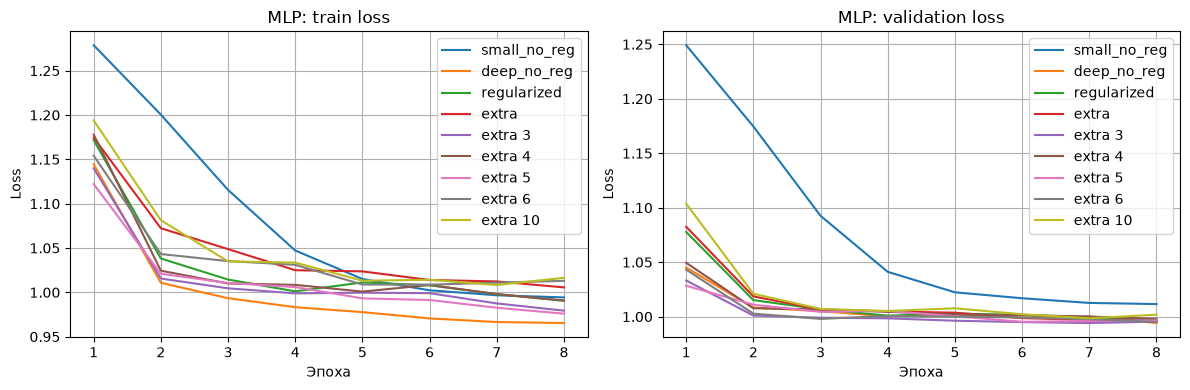

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, history in mlp_histories.items():
    # Постройте train loss и validation loss для каждой конфигурации
    axes[0].plot(history["epoch"], history["train_loss"], label=name)
    axes[1].plot(history["epoch"], history["loss"], label=name)

axes[0].set_title("MLP: train loss")
axes[1].set_title("MLP: validation loss")

for ax in axes:
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

**Вывод по эксперименту 1**

Соберите результаты в одну сравнительную таблицу. Постройте кривые обучения и сравните поведение моделей. Ответьте на вопросы:

* Какая MLP-конфигурация сработала лучше с точки зрения метрики PR-AUC? Что показывают остальные метрики этого запуска?
* Продолжает ли уменьшаться loss на обучающей выборке, когда loss на валидационной выборке уже растёт или перестаёт улучшаться?
* Помогли ли слои `Dropout` и `weight_decay` уменьшить переобучение?
* Почему числовых признаков может быть недостаточно для анализа тональности?

Если вы выполняли дополнительное задание, также расскажите, совпали ли ожидания от конфигурации с результатом.

Лучшей стала deep_no_reg по PR-AUC. Train loss снижается, а validation loss почти не улучшается, что указывает на переобучение. Dropout и weight_decay заметного улучшения не дали. Числовые признаки не отражают смысл и контекст текста. Дополнительная конфигурация ожидаемого улучшения не показала.

## Шаг 5. Эксперимент 2 - Embedding + mean pooling + MLP

В ходе второго эксперимента вы передадите в нейросеть тексты отзывов, а не только их числовые признаки. Используйте те же обучающую, валидационную и тестовую выборки, что и в первом эксперименте.

Далее вам нужно:

1. Подготовить текст - использовать готовую токенизацию, построить словарь только по обучающей выборке и перевести слова в индексы.
2. Собрать `Dataset` для текстов - реализовать длину датасета, получение одного объекта, обрезание длинных отзывов и пэддинг коротких отзывов до `MAX_LENGTH`.
3. Описать модель - получить эмбеддинги, исключить PAD-токены маской, усреднить эмбеддинги настоящих токенов и передать итоговый вектор в MLP.
4. Обучить модель через уже готовый `run_experiment`, оценить качество на тестовой выборке и сохранить веса через `state_dict`. Новый цикл обучения писать не нужно.
5. Провести анализ ошибок: найти конкретные примеры ответов типа FP и FN, чтобы объяснить, почему модель могла ошибиться.

### 5.1. Готовая подготовка текста

Код для токенизации и построения словаря уже почти полностью готов. Ваша задача - запустить ячейку и проверить, что словарь действительно строится **только по обучающей выборке**.

Обратите внимание на три специальных элемента логики:

- `PAD_IDX` - индекс для добивки коротких текстов до одной длины.
- `UNK_IDX` - индекс для редких или неизвестных слов. Подробнее этот элемент вы рассмотрите в следующем спринте.
- `text_to_indices` - функция, которая превращает текст в список индексов словаря.

После запуска проверьте размер словаря и первые элементы: это быстрый способ убедиться, что подготовка текста прошла корректно.

In [48]:
TOKEN_RE = re.compile(r"[а-яёa-z0-9]+", flags=re.IGNORECASE)
PAD_IDX = 0
UNK_IDX = 1


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def build_vocab(texts, min_freq: int = 2, max_size: int = 20_000) -> dict:
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for token, count in counter.most_common(max_size - len(vocab)):
        if count >= min_freq:
            vocab[token] = len(vocab)

    return vocab


def text_to_indices(text: str, vocab: dict) -> list[int]:
    return [vocab.get(token, UNK_IDX) for token in tokenize(text)]


vocab = build_vocab(train_df["text"], min_freq=2, max_size=20_000)
print(f"Размер словаря: {len(vocab)}")
print("Первые элементы словаря:", list(vocab.items())[:10])

Размер словаря: 18985
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('и', 2), ('в', 3), ('на', 4), ('не', 5), ('очень', 6), ('с', 7), ('что', 8), ('все', 9)]


### 5.2. Dataset и пэддинг

В этой части нужно дописать класс `ReviewsTextDataset`:

1. Верните количество текстов в датасете в `__len__`.
2. Возьмите текст по индексу и переведите его в индексы токенов в `__getitem__`.
3. Обрежьте слишком длинные отзывы до `MAX_LENGTH`.
4. Дополните короткие отзывы значением `PAD_IDX`, чтобы все последовательности в батче были одинаковой длины.
5. Создайте `DataLoader` для обучающей, валидационной и тестовой выборок.
6. Проверьте форму первого батча: ожидается матрица размера `batch_size` × `MAX_LENGTH` и тип `torch.long` для индексов токенов.

In [75]:
class ReviewsTextDataset(Dataset):
    def __init__(self, texts, target, vocab: dict, max_length: int = 120):
        self.texts = list(texts)
        self.target = np.array(target, dtype=np.float32)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        # Верните количество текстов
        return len(self.texts)

    def __getitem__(self, idx):
        ids = text_to_indices(self.texts[idx], self.vocab)

        # Обрежьте последовательность до max_length
        ids = ids[:self.max_length]

        # Если последовательность короче max_length, добавьте PAD_IDX
        if len(ids) < self.max_length:
            ids = ids + [PAD_IDX] * (self.max_length - len(ids))

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.target[idx], dtype=torch.float32),
        )


MAX_LENGTH = 120

text_loaders = {
    "train": DataLoader(
        ReviewsTextDataset(train_df["text"], y_train, vocab, MAX_LENGTH),
        batch_size=BATCH_SIZE,
        shuffle=True,
    ),
    "val": DataLoader(
        ReviewsTextDataset(val_df["text"], y_val, vocab, MAX_LENGTH),
        batch_size=BATCH_SIZE,
        shuffle=False,
    ),
    "test": DataLoader(
        ReviewsTextDataset(test_df["text"], y_test, vocab, MAX_LENGTH),
        batch_size=BATCH_SIZE,
        shuffle=False,
    ),
}

ids_batch, text_target_batch = next(iter(text_loaders["train"]))
print("ids_batch:", ids_batch.shape, ids_batch.dtype)
print("target_batch:", text_target_batch.shape, text_target_batch.dtype)

ids_batch: torch.Size([128, 120]) torch.int64
target_batch: torch.Size([128]) torch.float32


### 5.3. Модель с Embedding и mean pooling

В этой части нужно дописать `forward` модели `EmbeddingMLP`.

Что вам нужно сделать внутри `forward`:

1. Передать `input_ids` в `nn.Embedding`, чтобы каждому индексу токена соответствовал обучаемый вектор.
2. Умножить эмбеддинги на маску и посчитать длину каждого текста без PAD-токенов.
3. Выполнить mean pooling: усреднить эмбеддинги настоящих токенов и получить один вектор на отзыв.
4. Передать этот вектор в MLP-классификатор и вернуть логит.

In [76]:
class EmbeddingMLP(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_dim: int = 64,
        dropout: float = 0.3,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx,
        )
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.pad_idx = pad_idx

    def forward(self, input_ids):
        # 1. Получите эмбеддинги
        embeddings = self.embedding(input_ids)

        # 2. PAD-токены нужны только для выравнивания длин
        # Маска помогает не учитывать их при усреднении
        mask = (input_ids != self.pad_idx).unsqueeze(-1).float()
        masked_embeddings = embeddings * mask
        lengths = mask.sum(dim=1).clamp(min=1)

        # 3. Выполните mean pooling и передайте результат в MLP
        pooled = masked_embeddings.sum(dim=1) / lengths
        logits = self.classifier(pooled)
        return logits

### 5.4. Обучение, оценка и сохранение

Используйте тот же `run_experiment`, что и для MLP на числовых признаках. Это важно: цикл обучения и цикл валидации не нужно писать второй раз.

Что нужно сделать в коде:

1. Проверьте конфигурацию текстовой модели: размер эмбеддинга, размер скрытого слоя, `dropout`, `lr` (learning rate), `weight_decay` и число эпох.
2. Создайте объект `EmbeddingMLP` с нужным размером словаря.
3. Запустите обучение через `run_experiment`.
4. Посчитайте метрики на тестовой выборке с помощью `evaluate`.
5. Постройте график loss на обучающей и валидационной выборках.
6. Сохраните веса обученной текстовой модели через `state_dict`.

In [77]:
text_config = {
    "embedding_dim": 64,
    "hidden_dim": 64,
    "dropout": 0.3,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 8,
}

set_seed(RANDOM_STATE)

text_model = EmbeddingMLP(
    vocab_size=len(vocab),
    embedding_dim=text_config["embedding_dim"],
    hidden_dim=text_config["hidden_dim"],
    dropout=text_config["dropout"],
)

text_model, text_history = run_experiment(text_model, text_loaders, text_config)
text_test_metrics, y_true_text_test, y_prob_text_test = evaluate(
    text_model,
    text_loaders["test"],
    criterion,
    device,
)

display(pd.DataFrame([text_test_metrics]).round(4))

,pr_auc,roc_auc,precision,recall,f1,accuracy,loss
0,0.6322,0.941,0.47,0.8261,0.5991,0.8994,0.6503


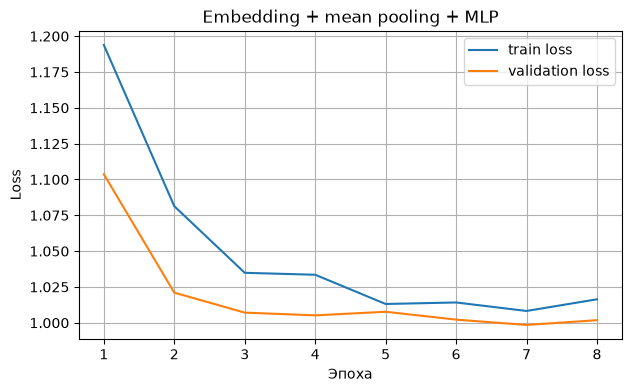

In [ ]:
plt.figure(figsize=(7, 4))

# Постройте train loss и validation loss для текстовой модели
plt.plot(text_history["epoch"], text_history["train_loss"], label="train loss")
plt.plot(text_history["epoch"], text_history["loss"], label="validation loss")

plt.title("Embedding + mean pooling + MLP")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [79]:
best_text_path = MODELS_DIR / "best_embedding_mlp.pt"

# Сохраните веса текстовой модели через state_dict
torch.save(text_model.state_dict(), best_text_path)

print(f"state_dict текстовой модели сохранён в: {best_text_path}")

state_dict текстовой модели сохранён в: models/best_embedding_mlp.pt


### 5.5. Анализ ошибок текстовой модели

После обучения нужно посмотреть на конкретные ошибки, чтобы разобраться, что именно не ухватывает модель.

Что нужно найти:

- Ложноположительные примеры (FP) - модель посчитала отзыв негативным (класс 1), хотя его истинный класс равен 0.
- Ложноотрицательные примеры (FN) - модель не распознала негативный отзыв (класс 1).

Для каждого типа ошибки проанализируйте текст, вероятность негативного отзыва и возможную причину. Обратите внимание на смешанную тональность, короткие отзывы, отрицания, сарказм, длинный контекст и потерю порядка слов при mean pooling.

Также учитывайте возможный шум разметки: `target` получен из пользовательской оценки, а не из ручного анализа текста.

In [80]:
error_analysis = test_df[["text", "target", "review_len_words"]].copy()
error_analysis["prob_negative"] = y_prob_text_test
error_analysis["prediction"] = (error_analysis["prob_negative"] >= 0.5).astype(int)

# Найдите false positive: модель считает отзыв негативным, но target = 0
# Полезно отсортировать такие примеры по prob_negative по убыванию
false_positive = (
    error_analysis[
        (error_analysis['prediction'] == 1) &
        (error_analysis['target'] == 0)
    ].sort_values('prob_negative', ascending=False)
)

# Найдите false negative: модель пропускает негативный отзыв
# Полезно отсортировать такие примеры по prob_negative по возрастанию
false_negative = (
    error_analysis[
        (error_analysis['prediction'] == 0) &
        (error_analysis['target'] == 1)
    ].sort_values('prob_negative')
)

print("False positive: модель считает отзыв негативным, но target = 0")
display(false_positive)

print("False negative: модель пропускает негативный отзыв")
display(false_negative)

False positive: модель считает отзыв негативным, но target = 0


,text,target,review_len_words,prob_negative,prediction
8876,"Консультантов в зале нет ,выбор не большой",0,7,0.998154,1
3917,Обычная поликлиника. Со вмеми плюсами и минусами,0,7,0.997992,1
10024,"Контора с понятиями! Встречают как надо,обещания выполняют. Справки не нужны,можно даже ВИЧ инфицированным работать. Главное при отлове птиц не повредить кожный покров. Чтоб не попасть в просак",0,29,0.995272,1
7011,"Оказались закрыты, без всяких объявлений, даже на сайте не видно было, зря потратил время и деньги за доставку груза к филиалу. Целых три звезды за то, что сам сглупил и заранее не позвонил.",0,33,0.993966,1
4011,"Медленно, печально,на кассе такое ощущение что просто тянут время.\nОдин сотрудник в отделе декора,которому просто не разорваться",0,19,0.992834,1
...,...,...,...,...,...
2593,"Кафе на 4 с минусом. \nИнтерьер: это пристройка к жилому зданию, небольшая. Внутри портят вид нарисованные кирпичи с непонятной зеленью, видимо хотели придать вид старой кирпичной стены, заросшей плющом. Не получилос...",0,161,0.526806,1
4542,"Клиника замечательная, очень вежливый персонал, уютно. Прием у Никиты Лизикова выше всяких похвал. Изменения у дочки не только видны со стороны визуально, ребенок говорит, что стало легко дышать. Эмоциональное состоя...",0,43,0.519386,1
1259,Для фотосесий именно для попараций пишу. Маленькая эфелева башня как даже фотографировался. Находится около почты на лескова. Приезжайте и почувствуйте Францию на лесков!!! Всем хорошего дня!,0,26,0.515473,1
10587,"Очень хорошая продавец. Широкий выбор вин. На этом все. Купили по акции две бутылки вина Шардоне, сухое белое, теперь не знаем что с ним делать. Вкусовые качества оставляют желать лучшего. Выпить невозможно, подарить...",0,41,0.512575,1


False negative: модель пропускает негативный отзыв


,text,target,review_len_words,prob_negative,prediction
9989,"Цены зашкаливают, не для нашего города.",1,6,0.000058,0
8255,"И место хорошее и обслуживание замечательно и вежливы и приветливы и аккуратны , Одно очень расстроило Мороженное Отвратительное ледышки вместо замечательного лакомства",1,21,0.001033,0
5658,"Не нравиться, особенно если ехать с города! Если есть варианты и альтернативы , туда не поеду 😩",1,15,0.005401,0
1903,Очень долго ходить автобус,1,4,0.013872,0
277,"Проблема попасть к терапевту и эндокринологу, проблема выстоять в очереди для сдачи крови на анализы, особенно для пожилых людей, за то за деньги без очереди . вывод положенное по омс лечение практически не доступ...",1,39,0.022408,0
11718,Очень бедная больница. Все лекарства для лечения покупали сами .. Также была аллергия у ребёнка ни кто не дал даже таблетки от аллергии. Сказали нету... Дети и взрослые лежат все вместе. Одно радовала то что женщин...,1,45,0.035395,0
10010,"Раньше была классная шаверма, но со временем начали портиться. Начали экономить на соусе, в шаверму кладут буквально чайную ложку. Из за этого шаверма становится сухой. Очень хочу чтобы исправились",1,29,0.069598,0
7559,"Первый раз в жизни решила обратиться к специалистам, так как у меня была роспись. Хотелось быть красивой. У девочек очень хороший клиентский сервис, они оч внимательные, подождали меня, собрали. Но собрали просто ужа...",1,64,0.079736,0
5214,Компания полное днище. Скорость восстановления соединения с интернетом на нуле. Цены высокие. Рассмотрение обращений долгое. На своих клиентов наплевать. Пользуются своей монополией. Не советую. Если есть альтернатив...,1,45,0.100898,0
3343,"Место хорошее, парк сохранил кусочками советскую задумку планировку, дендрологический, но заброшен, кто-то начинал переделывать,, но,,,,,,, впечатление одичавшего лес очка, своя предисловии, в это есть отдых от цивил...",1,55,0.134704,0


**Анализ найденных ошибок**

Заполните два коротких списка:

- FP - какие слова или фрагменты могли подтолкнуть модель посчитать отзыв отрицательным, хотя `target = 0`.
- FN - почему модель могла пропустить отзыв класса 1. Возможные причины: редкие слова, длинный контекст, отрицания или слабые негативные маркеры.

Отдельно отметьте, могли ли дисбаланс классов и разметка по пользовательским оценкам повлиять на ошибки: отзывы с оценкой 3–5 попадают в `target = 0`, хотя текст иногда бывает нейтральным или смешанным.

**Вывод по эксперименту 2**

Ответьте на вопросы:

* Насколько текстовая модель лучше или хуже MLP на числовых признаках по PR-AUC? Что показывают остальные метрики?
* Какие ошибки вы нашли среди false positive и false negative?
* Какие причины ошибок кажутся наиболее вероятными?
* Какие ограничения остаются у mean pooling?
* Почему текстовое представление обычно даёт модели больше информации, чем поверхностные числовые признаки?

FP возникают из-за отдельных негативных слов и фрагментов в целом нейтральных или положительных отзывов, особенно при смешанном контексте. FN чаще связаны с короткими отзывами, слабой негативной окраской и случаями, где негатив выражен неочевидно. Дисбаланс классов и разметка по пользовательским оценкам добавляют шум, поскольку оценка не всегда точно отражает тональность текста. Текстовая модель хорошо использует содержание отзывов, но mean pooling теряет порядок слов и часть контекста, из-за чего возникают ошибки на сложных формулировках. Числовые признаки дают меньше информации о содержании, но могут быть полезны как дополнительные признаки.

## Шаг 6. Итоговое сравнение

Для честного выбора лучшей числовой MLP используйте PR-AUC на валидационной выборке, потому что положительный класс редкий. ROC-AUC, precision, recall, F1 и accuracy нужны для дополнительной диагностики. Метрики на тестовой выборке анализируем уже после выбора модели.

Ниже соберите сравнительную таблицу минимум с двумя строками: лучшая MLP на числовых признаках и `Embedding + pooling + MLP`.

In [ ]:
final_comparison = pd.DataFrame(
    [
        {
            "Подход": "MLP на числовых признаках",
            "PR-AUC test": best_numeric_test_metrics["pr_auc"],
            "ROC-AUC test": best_numeric_test_metrics["roc_auc"],
            "Precision": best_numeric_test_metrics["precision"],
            "Recall": best_numeric_test_metrics["recall"],
            "F1": best_numeric_test_metrics["f1"],
            "Ограничения": "Не учитывает смысл и контекст текста",
        },
        {
            "Подход": "Embedding + pooling + MLP",
            "PR-AUC test": text_test_metrics["pr_auc"],
            "ROC-AUC test": text_test_metrics["roc_auc"],
            "Precision": text_test_metrics["precision"],
            "Recall": text_test_metrics["recall"],
            "F1": text_test_metrics["f1"],
            "Ограничения": "Mean pooling теряет порядок слов и контекст",
        },
    ]
)

display(final_comparison)

,Подход,PR-AUC test,ROC-AUC test,Precision,Recall,F1,Ограничения
0,MLP на числовых признаках,0.353148,0.794769,0.228330,0.670807,0.340694,Не учитывает смысл и контекст текста
1,Embedding + pooling + MLP,0.632156,0.940984,0.469965,0.826087,0.599099,Mean pooling теряет порядок слов и контекст


## Итоговые выводы

Сформулируйте итоговые выводы. Ответьте на вопросы:

* Какой подход показал лучшее качество?
* По каким метрикам преимущество особенно заметно?
* Что текстовая модель узнала из того, что упускала модель на числовых признаках?
* В каких ситуациях числовые признаки всё же могут быть полезны?
* Какие ограничения есть у mean pooling?
* Как на результат могли повлиять дисбаланс классов и разметка, полученная из пользовательских оценок?
* Какой следующий эксперимент вы бы предложили?

Лучше всего показала себя модель Embedding + pooling + MLP. Она значительно превзошла числовую MLP по всем метрикам: PR-AUC - 0.632 против 0.353, ROC-AUC - 0.941 против 0.795, F1 - 0.599 против 0.341. Текстовая модель смогла учитывать содержание отзывов, которое недоступно числовым признакам. При этом mean pooling теряет порядок слов и часть контекста. Числовые признаки всё же могут быть полезны как дополнительные признаки. На результат также влияют дисбаланс классов и шумная разметка по пользовательским оценкам. Следующим экспериментом стоит попробовать более продвинутое представление текста, например предобученные эмбеддинги.

## Чек-лист самопроверки

До сдачи проекта ревьюеру убедитесь в том, что выполнили все указанные ниже действия:

- Разделение на обучающую, валидационную и тестовую выборки выполнено со стратификацией в пропорции 70:15:15.
- Оба эксперимента используют одно и то же разделение на выборки.
- Числовые признаки из текста извлечены через pandas.
- `federal_district` преобразован с помощью One-Hot Encoder.
- `StandardScaler` и `OneHotEncoder` обучены только на обучающей выборке.
- `Dataset` и `DataLoader` реализованы для числового и текстового эксперимента.
- Цикл обучения содержит порядок `zero_grad` → `forward` → `loss` → `backward` → `step`.
- Цикл валидации использует `model.eval()` и `torch.no_grad()`.
- Проведено минимум три конфигурации MLP.
- При желании выполнена дополнительная четвёртая конфигурация MLP. Она сопровождается обоснованием выбора.
- Есть графики loss на обучающей и валидационной выборках.
- Есть метрики на валидационной и тестовой выборках.
- Лучшая модель сохранена через `state_dict`.
- Есть сравнительная таблица метрик на тестовой выборке.
- Есть анализ ошибок текстовой модели с конкретными примерами и объяснением возможных причин.
- Написаны выводы по EDA, обоим экспериментам и итоговому сравнению.